# Importando as principais bibliotecas que serão utilizadas no projeto.


In [170]:
import numpy as np
import matplotlib.pyplot as plt

In [171]:
# Definindo o estilo
plt.style.use("dark_background")
plt.rcParams['figure.figsize'] = [10,8]

# Criando dataset

In [52]:
# x = temperatura em graus Celsius
# w = Curva da reta
# b = bias

# Equação da reta
def get_linear_curve(x, w, b = 0, noise_scale = 0):
  return w * x + b + noise_scale * np.random.randn(x.shape[0])

# np.random.randn(x.shape[0]) = Ruído

In [22]:
x = np.arange(-10,31,1)
Y = get_linear_curve(x,1.8,32, noise_scale=5)

In [23]:
x.shape, Y.shape

((41,), (41,))

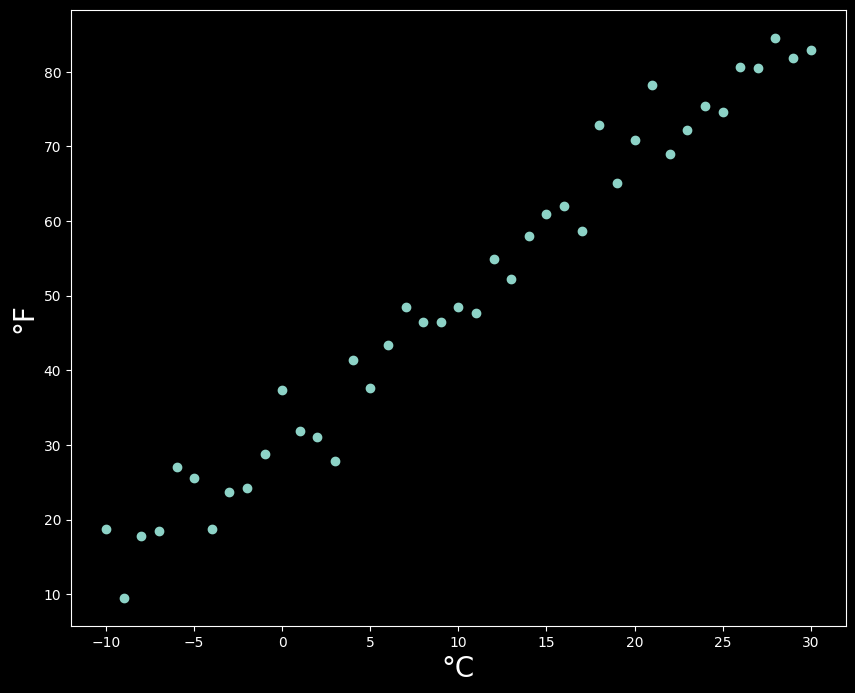

In [24]:
plt.scatter(x,Y)
plt.xlabel("°C", fontsize=20);
plt.ylabel("°F", fontsize=20);

# Modelo



- Inicializar os pesos e bias
- Feedforward
- Calcular Perda
- Backprogation

In [172]:
# Inicializar

w = np.random.randn(1)
b = 0

In [173]:
# Geralmente entrada é encontrada como "Input" utilizei entrada para nível de aprendizagem

def forward(x, w, b):
  return w * x + b

In [174]:
# Função de perda ou erro
def mse(Y,y):
  return (Y-y) ** 2

In [175]:
# Exemplo de uso

v = np.array([1, 2, 3, 4, 5])
u = np.array([1.1, 2.2, 3.4, 4.8, 6])
mse(v,u)

array([0.01, 0.04, 0.16, 0.64, 1.  ])

In [176]:
# target = valor real = valor quero chegar
#lr = learning rating = taxa de aprendizado

# backpropagation serve para calcular a derivada do erro em relação ao peso e a derivada do erro com relação ao bias.

def backpropagation(x, outputs, target, w, b, lr):
  dw = lr * ( -2 * x * (target - outputs)).mean() #Geralmente não tem o mean mas como são vários valores por ser um vetor está tirando a média
  db = lr * ( -2 * (target - outputs)).mean()

  w -= dw
  b -= db

  return w,b

In [177]:
def model_fit(x,target, w, b, epochs = 100, lr = 0.01):
  for epoch in range(epochs):

    outputs = forward(x, w, b)
    perda = np.mean(mse(target,outputs))
    w,b = backpropagation(x, outputs, target, w, b, lr)

    if (epoch+1) % 10 == 0:
      print(f'Epoch: [{epoch+1}] Perda: [{perda:.4f}])')


  return w, b



In [178]:
x = np.arange(-10,31,1)
Y = get_linear_curve(x, w = 1.8, b = 32)

In [179]:
# Inicialização

w = np.random.randn(1)
b = np.zeros(1)


In [184]:
w, b = model_fit(x, Y, w, b, epochs = 1000, lr = 0.001)
print('')
print(f'W = {w[0]:.3f} B = {b[0]:.3F} ')

Epoch: [10] Perda: [0.5364])
Epoch: [20] Perda: [0.5241])
Epoch: [30] Perda: [0.5120])
Epoch: [40] Perda: [0.5002])
Epoch: [50] Perda: [0.4887])
Epoch: [60] Perda: [0.4774])
Epoch: [70] Perda: [0.4664])
Epoch: [80] Perda: [0.4557])
Epoch: [90] Perda: [0.4452])
Epoch: [100] Perda: [0.4349])
Epoch: [110] Perda: [0.4249])
Epoch: [120] Perda: [0.4151])
Epoch: [130] Perda: [0.4056])
Epoch: [140] Perda: [0.3962])
Epoch: [150] Perda: [0.3871])
Epoch: [160] Perda: [0.3782])
Epoch: [170] Perda: [0.3695])
Epoch: [180] Perda: [0.3609])
Epoch: [190] Perda: [0.3526])
Epoch: [200] Perda: [0.3445])
Epoch: [210] Perda: [0.3366])
Epoch: [220] Perda: [0.3288])
Epoch: [230] Perda: [0.3212])
Epoch: [240] Perda: [0.3138])
Epoch: [250] Perda: [0.3066])
Epoch: [260] Perda: [0.2996])
Epoch: [270] Perda: [0.2927])
Epoch: [280] Perda: [0.2859])
Epoch: [290] Perda: [0.2793])
Epoch: [300] Perda: [0.2729])
Epoch: [310] Perda: [0.2666])
Epoch: [320] Perda: [0.2605])
Epoch: [330] Perda: [0.2545])
Epoch: [340] Perda:

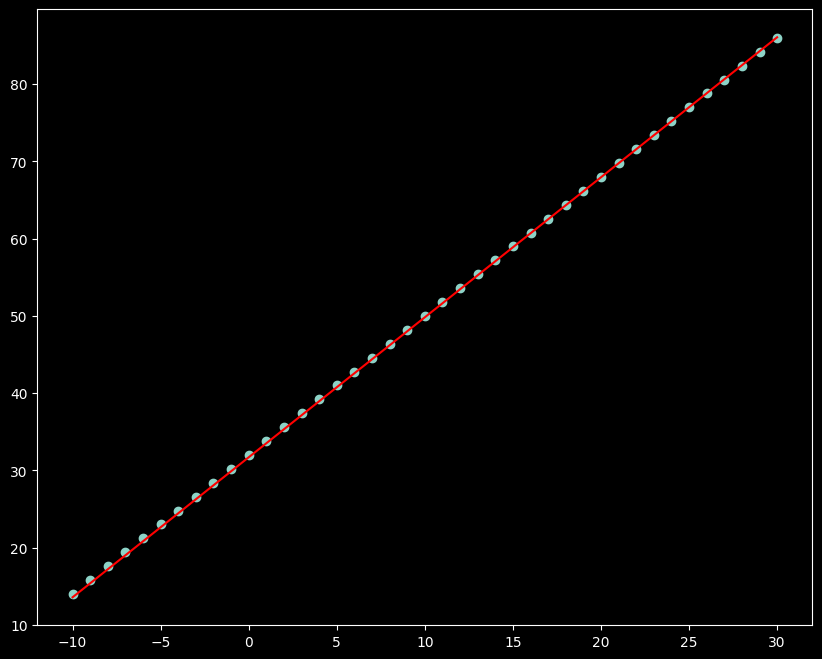

In [185]:
plt.scatter(x,Y)
plt.plot(x, w * x + b, color='red');
